<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/> 

# Statistics for Feature Selection in Machine Learning
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

# Activity 1 (10 minutes)

---

# Consolidate



### 1. The Fundamental Difference

According to the introductory example with the saturating curve (Practice Hours vs. Performance), why was Spearman's correlation able to achieve a perfect score of  while Pearson’s correlation was not?

### 2. Assumption Requirements

Compare the "Main Assumptions" for both methods. What must be true about the relationship between two variables for Pearson’s correlation to be the appropriate choice, and how does this differ from the requirements for Spearman’s?

### 3. Impact of Outliers

In the example where a single data point was changed to  (the outlier), Pearson's correlation coefficient dropped significantly. Why is Pearson’s correlation considered "sensitive" to such data points, and why does Spearman’s correlation remain "robust" in the same scenario?

### 4. The Mechanism of Ranking

Look at the section where the  and  values are converted into ranks. How does the mathematical process of "ranking" specifically prevent a massive outlier (like the value ) from dominating the correlation result compared to using the raw values?



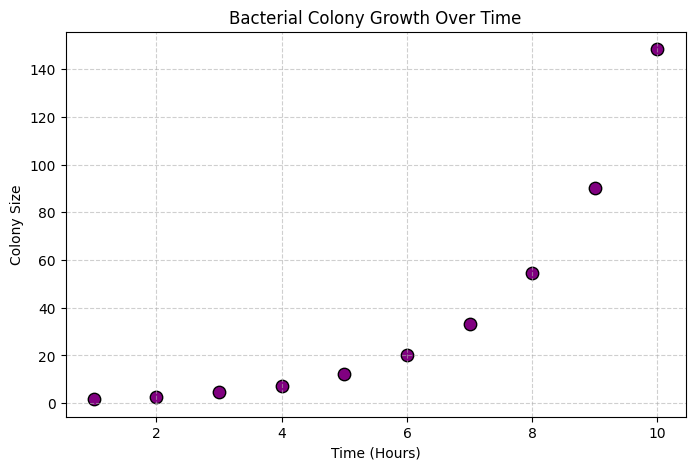

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate Exponential Growth Data
np.random.seed(7)
time = np.arange(1, 11)
growth = np.exp(time / 2) # Exponential growth

df_ex = pd.DataFrame({'Time': time, 'Colony_Size': growth})

# 2. Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(df_ex['Time'], df_ex['Colony_Size'], color='purple', s=80, edgecolor='black')
plt.title('Bacterial Colony Growth Over Time')
plt.xlabel('Time (Hours)')
plt.ylabel('Colony Size')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [2]:
print(f"Spearman:{df_ex.corr(method='spearman')}")
print(f"Pearson:{df_ex.corr(method='pearson')}")

Spearman:             Time  Colony_Size
Time          1.0          1.0
Colony_Size   1.0          1.0
Pearson:                 Time  Colony_Size
Time         1.000000     0.865379
Colony_Size  0.865379     1.000000





# Correlation Analysis Recap

Based on the plot you just generated and the statistical principles we've covered, answer the following questions to test your intuition:

### 1. The Prediction 

Before running the calculation, which correlation coefficient (Pearson or Spearman) do you expect to be **exactly 1.0**?

* **Hint:** Think about the "monotonic" property vs. the "linear" property.

### 2. Linearity Assessment 

Does this specific dataset (the bacterial growth curve) meet the **Main Assumption** required for Pearson’s correlation to be the most accurate measure? Why or why not?

### 3. The Researcher's Choice 

If you were writing a scientific report on this colony's growth, which correlation method would you report as the primary evidence of a **"perfectly consistent"** relationship?

> **Think about it:** Would a Pearson score of  accurately represent how "perfectly" this colony is following its growth rule?

### 4. The Moment of Truth 

Run the final cell to print `pearson_corr` and `spearman_corr`.

* **Was your prediction in Question 1 correct?**
* **Reflect:** If the Pearson correlation isn't , does that mean the relationship is "weak," or just that it's "non-linear"?




In [3]:
print(f"Spearman:{df_ex.corr(method='spearman')}")
print(f"Pearson:{df_ex.corr(method='pearson')}")

Spearman:             Time  Colony_Size
Time          1.0          1.0
Colony_Size   1.0          1.0
Pearson:                 Time  Colony_Size
Time         1.000000     0.865379
Colony_Size  0.865379     1.000000


# Activity 2 (15 minutes)



---

### 🧪 Chi-Squared & Feature Selection Challenge

#### 1. The "Frequency" Rule of Thumb (Research)

The Chi-Squared test relies on **Expected Frequencies**. Research the **"Rule of 5"** for Chi-Squared tests. What happens to the reliability of your -value if a specific cell (like "High Dose & Improved") has an expected count of only 2 or 3? What alternative test (often named after a famous statistician) is usually recommended for these small-sample scenarios?

#### 2. Feature Selection: Strength of Association (Research)

In your code, the Chi-Squared test tells you if an association **exists** (-value), but it doesn't tell you how **strong** it is. Research **Cramér's V**. How does this metric act like a "correlation coefficient" for categorical variables, and why is it useful to look at both the -value and Cramér's V when deciding which features to keep for a machine learning model?

#### 3. Nominal vs. Ordinal Logic (Comprehension)

Look closely at your code results: the **Standard Chi-Squared** was *not* significant (), but the **Test for Trend** *was* significant ().

* In your own words, explain why treating "Placebo, Low, High" as a sequence (a ladder) provided a different result than treating them as three independent, unrelated buckets.
* Which result is more "trustworthy" if we know for a fact that the dosage levels increase in intensity?

#### 4. The "Null Hypothesis" Intuition (Comprehension/Research)

In the context of your contingency table (Improved vs. No Change), what exactly is the **Null Hypothesis ()** that the Chi-Squared test is trying to disprove?

* **A:** The dosage causes the improvement.
* **B:** There is no relationship; the distribution of "Improved" is roughly the same regardless of which dose a person took.
* **C:** The "High Dose" is better than the "Placebo."

#### 5. Impact of Sample Size (Comprehension/Research)

Imagine you kept the exact same percentages (10%, 15%, 21% improvement) but increased the sample size from **100** people per group to **10,000** people per group.

* Without running any code, do you think the -value would get **larger** or **smaller**?
* **Discussion:** Why might a very large dataset make even a tiny, meaningless difference look "statistically significant"?




# CODE SNIPPET

Use the syntax from the example in class to try and put this all together you might have to remember how p value thresholds are interpreted in the context of a Hypothesis Test.

In [ ]:
# **HINT** this is not the ordinal case

import pandas as pd
import numpy as np
from scipy.stats import ____  # 1. Import the correct test function

# 1. Data Setup (3x3 Contingency Table)
# Rows: North, South, West | Columns: Chrome, Safari, Firefox
data = np.array([
    [150, 80,  70],  # North
    [100, 120, 80],  # South
    [90,  70,  140]  # West
])

df_browsers = pd.DataFrame(data, 
                           columns=[____, ____, ____], # 2. Add Column Names
                           index=[____, ____, ____])   # 3. Add Index Names

# 2. Perform the Test
# This function returns: chi2, p-value, degrees of freedom, and expected frequencies
____, p_val, dof, expected = ____(data) # 4. Call the function

# 3. Evaluation Logic
alpha = 0.05
print(f"P-value calculated: {p_val:.4f}")

if p_val < ____: # 5. Significance threshold
    print("Decision: ____ the Null Hypothesis. Region and Browser are dependent.")
else:
    print("Decision: ____ to Reject the Null Hypothesis. No association found.")

---

# Activity 3 (15 minutes)

# Follow the syntax from class example!

In [ ]:
import pandas as pd
import numpy as np
# 1. Import only the ANOVA function
from sklearn.feature_selection import ____ 

# --- [Data Setup] ---
np.random.seed(101)
n = 150
# Annual Spend using a Gamma distribution (Scale/Shape)
spend = np.random.gamma(shape=5.0, scale=2000.0, size=n) 
# Target: 0=Bronze, 1=Silver, 2=Gold
tiers = np.random.choice([0, 1, 2], size=n)

df_store = pd.DataFrame({"Annual_Spend": spend, "Loyalty_Tier": tiers})

# 2. Define your Feature (X) and Target (y)
# X must be a 2D structure (DataFrame)
X = df_store[[____]] 
y = df_store[____]

# 3. Run the ANOVA F-test
# Returns: (F-statistics array, p-values array)
F_score, p_val = ____(X, y)

# 4. Extract and Print results
print(f"F-statistic: {____[0]:.2f}")
print(f"P-value: {____[0]:.4f}")

# Complete the report!



---

### 📑 Feature Selection Report: Annual Spend vs. Loyalty Tier

#### 1. Statistical Assumptions

Before relying on the results, we must acknowledge the three core assumptions of the ANOVA F-test:

* **Independence**: Each customer's spend is independent of others.
* **________________**: The continuous feature (Annual_Spend) should ideally follow a bell-shaped distribution within each group.
* **Homogeneity of ________________**: The spread (variance) of the data should be roughly equal across all loyalty tiers.

#### 2. The Null Hypothesis ()

The Null Hypothesis for this test was:

> "There is **____________________** in the average **Annual_Spend** across the Bronze, Silver, and Gold loyalty tiers."

#### 3. Evaluation of the P-value

We used a significance threshold () of **0.05**.

* Our calculated P-value was: `________`
* Since the P-value is **[greater than / less than]** 0.05, we **[reject / fail to reject]** the Null Hypothesis.

#### 4. Interpretation of the F-statistic

Our F-statistic was: `________`
A **[high / low]** F-statistic indicates that the "between-group" variance (the distance between the means of the tiers) is much **[larger / smaller]** than the "within-group" variance (the random noise inside each tier).

#### 5. Final Conclusion & Feature Selection

Based on these results, we conclude that **Annual_Spend** is a **[statistically significant / non-significant]** feature.

* **Decision:** We should **[keep / drop]** this feature in our machine learning model because it **[does / does not]** provide a clear signal to distinguish between the three loyalty tiers.



